# 06 · Исследование: нужен ли граф, или хватит CatBoost

**Вопрос.** Графовая модель HGT сложнее, дольше учится и хуже объясняется, чем
CatBoost. Оправдана она, только если заметно лучше. Здесь мы проверяем это
честно: все модели учатся на одной и той же выборке, одном разбиении и
оцениваются одним кодом (`src/lctrend/modeling/training/research.py`).

**Что сравниваем**

| Эксперимент | Что это | Зачем |
|---|---|---|
| **случайная модель** | ничего не знает, PR-AUC = доля слабых сигналов | нижняя планка |
| **правило** | один признак как оценка; какой и с каким знаком — выбрано на valid | что можно получить «руками», без ML |
| **CatBoost: только свои признаки** | признаки самой технологии | вклад самой истории технологии |
| **CatBoost: + соседи** | плюс агрегаты окружения (основная модель пайплайна) | вклад окружения в табличном виде |
| **HGT** | графовая сеть на подграфах, соседи несут свои признаки | вклад окружения как графа |
| **HGT: соседи пустые** | тот же HGT, но у соседних технологий нет признаков | важно ли, *какие* соседи, или только сколько их |
| **CatBoost на перемешанных метках** | ответы в train перемешаны случайно | проверка на утечку: должен упасть до случайного уровня |
| **стекинг** (из 04) | CatBoost + вероятность HGT как признак | даёт ли HGT что-то сверх CatBoost |

**Как читать результаты**

- Модели со случайностью обучаются с разными *зёрнами* (seed). Разница
  между моделями меньше разброса между зёрнами — не находка, а шум.
- **Главная метрика — PR-AUC на test**: технологии, которых модели не видели и
  которые появились позже обучающих. Правило выбора модели (по valid)
  зафиксировано заранее.
- 95% доверительный интервал считается пересэмплированием *семейств*
  технологий; если интервалы двух моделей сильно перекрываются, уверенно
  сказать «одна лучше другой» нельзя.

**Где мы в цепочке:** 01 выгрузка → 02 разметка → 03 выборка → 04 обучение → 05 граф → **06 исследование**.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
from lab import *
from IPython.display import display, Markdown

from lctrend.modeling.training.research import run_research

RESEARCH = RUN_DIR / "research.json"
# Полный прогон: 5 зёрен CatBoost × 3 варианта и 3 зерна × 2 варианта HGT — это
# десятки минут. Готовые результаты не пересчитываются, пока RERUN = False.
RERUN = not RESEARCH.exists()
if RERUN:
    run_research(CONFIG)
research = json.loads(RESEARCH.read_text(encoding="utf-8"))
results = pd.DataFrame(research["results"])
display(Markdown(
    f"Выборка: train {num(research['rows']['train'])}, valid {num(research['rows']['valid'])}, "
    f"test {num(research['rows']['test'])} строк; признаков своих {research['own_features']}, "
    f"всего с соседями {research['all_features']}."
))

C:\tema\Code\hackathons\хакатон\анализ трендов\LCTrendSearch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\tema\Code\hackathons\хакатон\анализ трендов\LCTrendSearch\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Выборка: train 5 300, valid 1 116, test 1 336 строк; признаков своих 62, всего с соседями 94.

## 1. Сводная таблица

**Как читать.** Для каждого эксперимента — среднее по зёрнам и разброс (±
стандартное отклонение). «Во сколько раз лучше случайной» — PR-AUC на test,
делённая на долю слабых сигналов в test: 1 — модель ничего не умеет.

In [2]:
NAME = {"random": "случайная модель", "rule": "правило (один признак)",
        "catboost_own": "CatBoost: только свои признаки", "catboost": "CatBoost: + соседи",
        "hgt": "HGT", "hgt_blank_neighbours": "HGT: соседи пустые",
        "catboost_shuffled": "CatBoost на перемешанных метках"}
ORDER = list(NAME)
grouped = results.groupby("experiment").agg(
    зёрен=("valid_pr_auc", "size"),
    valid_pr_auc=("valid_pr_auc", "mean"),
    test_pr_auc=("test_pr_auc", "mean"),
    test_pr_auc_std=("test_pr_auc", "std"),
    test_roc_auc=("test_roc_auc", "mean"),
    test_f1=("test_f1", "mean"),
).reindex(ORDER).dropna(how="all")
rate = results.loc[results.experiment == "random", "test_pr_auc"].iloc[0]
grouped["во сколько раз лучше случайной"] = grouped.test_pr_auc / rate
report = json.loads((MODELS_DIR / "report.json").read_text(encoding="utf-8")) if (MODELS_DIR / "report.json").exists() else None
if report and "stacked" in report["models"]:
    s = report["models"]["stacked"]["metrics"]
    grouped.loc["stacked"] = {"зёрен": 1, "valid_pr_auc": s["valid"].get("pr_auc"), "test_pr_auc": s["test"].get("pr_auc"),
                              "test_pr_auc_std": None, "test_roc_auc": s["test"].get("roc_auc"),
                              "test_f1": s["test"].get("at_valid_f1_threshold", {}).get("f1"),
                              "во сколько раз лучше случайной": s["test"].get("pr_auc") / rate}
    NAME["stacked"] = "стекинг HGT → CatBoost (из 04)"
table = grouped.rename(index=NAME).rename(columns={
    "valid_pr_auc": "PR-AUC valid", "test_pr_auc": "PR-AUC test", "test_pr_auc_std": "± по зёрнам",
    "test_roc_auc": "ROC-AUC test", "test_f1": "F1 test"}).rename_axis("эксперимент")
rule_name = results.loc[results.experiment == "rule", "rule"].iloc[0] if "rule" in results.columns else ""
display(table.round(3))
display(Markdown(f"Правило, выбранное на valid: `{rule_name}` (знак — направление: «−» значит «меньше — больше похоже на сигнал»)."))

,зёрен,PR-AUC valid,PR-AUC test,± по зёрнам,ROC-AUC test,F1 test,во сколько раз лучше случайной
эксперимент,,,,,,,
случайная модель,1,0.172,0.108,NaN,0.500,NaN,1.000
правило (один признак),1,0.304,0.202,NaN,0.679,0.362,1.872
CatBoost: только свои признаки,5,0.368,0.275,0.01975,0.738,0.331,2.552
CatBoost: + соседи,5,0.374,0.281,0.027472,0.730,0.291,2.606
HGT,3,0.376,0.238,0.018032,0.726,0.290,2.208
HGT: соседи пустые,3,0.363,0.242,0.025065,0.734,0.355,2.247
CatBoost на перемешанных метках,5,0.199,0.126,0.02985,0.498,0.199,1.167
стекинг HGT → CatBoost (из 04),1,0.393,0.262,None,0.693,0.331,2.428


Правило, выбранное на valid: `−nb_comentioned_count` (знак — направление: «−» значит «меньше — больше похоже на сигнал»).

## 2. Картина по зёрнам

**Как читать.** Каждая точка — один запуск с одним зерном; вертикальная черта —
среднее; пунктир — случайная модель. Если облака точек двух моделей
перекрываются, разница между ними в пределах шума.

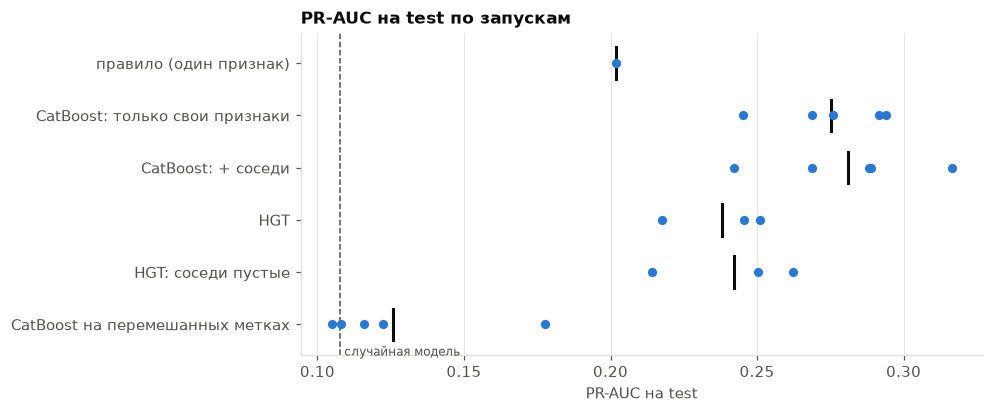

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.8))
shown = [e for e in ORDER if e in set(results.experiment) and e != "random"]
for y, experiment in enumerate(shown):
    values = results.loc[results.experiment == experiment, "test_pr_auc"].dropna()
    ax.scatter(values, [y] * len(values), color=BLUE, s=36, zorder=3)
    ax.plot([values.mean()] * 2, [y - 0.3, y + 0.3], color="#0b0b0b", linewidth=2)
ax.axvline(rate, color=MUTED, linewidth=1, linestyle="--")
ax.text(rate, len(shown) - 0.4, " случайная модель", color=MUTED, fontsize=8)
ax.set_yticks(range(len(shown)), [NAME[e] for e in shown])
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("PR-AUC на test")
ax.set_title("PR-AUC на test по запускам")
plt.show()

## 3. Ответы на вопросы исследования

Выводы ниже считаются из таблицы выше, а не написаны заранее.

In [4]:
def stats(name):
    values = results.loc[results.experiment == name, "test_pr_auc"].dropna()
    return values.mean(), (values.std() if len(values) > 1 else 0.0)

def compare(a, b):
    (ma, sa), (mb, sb) = stats(a), stats(b)
    noise = max(sa, sb, 0.005) * 2
    if ma - mb > noise:
        return f"{NAME[a]} лучше: {ma:.3f} против {mb:.3f} (разница {ma - mb:+.3f} больше двух разбросов по зёрнам)"
    if mb - ma > noise:
        return f"{NAME[b]} лучше: {mb:.3f} против {ma:.3f} (разница {mb - ma:+.3f} больше двух разбросов по зёрнам)"
    return f"разницы нет: {ma:.3f} и {mb:.3f}, отличие {ma - mb:+.3f} в пределах разброса по зёрнам (±{noise / 2:.3f})"

shuffled, _ = stats("catboost_shuffled")
best_ml = max(("catboost", "hgt", "catboost_own"), key=lambda e: stats(e)[0])
lines = [
    f"**Модель вообще учится?** Лучшая модель ({NAME[best_ml]}) даёт PR-AUC {stats(best_ml)[0]:.3f} при случайном "
    f"уровне {rate:.3f} — в {stats(best_ml)[0] / rate:.1f} раза лучше.",
    f"**Есть ли утечка?** На перемешанных метках PR-AUC {shuffled:.3f} против случайного {rate:.3f}: "
    + ("модель падает до случайного уровня — признаки не подсказывают ответ." if abs(shuffled - rate) < 0.05 + rate * 0.5
       else "выше случайного — стоит поискать утечку."),
    f"**Лучше ли ML, чем простое правило?** {compare('catboost', 'rule')}.",
    f"**Помогают ли соседи в CatBoost?** {compare('catboost', 'catboost_own')}.",
    f"**HGT или CatBoost?** {compare('hgt', 'catboost')}.",
    f"**Важны ли признаки соседей для HGT?** {compare('hgt', 'hgt_blank_neighbours')}.",
]
if report and "stacked" in report["models"]:
    st = report["models"]["stacked"]
    lines.append(
        f"**Добавляет ли HGT что-то к CatBoost (стекинг)?** В 04: стекинг PR-AUC test "
        f"{st['metrics']['test'].get('pr_auc', float('nan')):.3f} против CatBoost "
        f"{report['models']['catboost']['metrics']['test'].get('pr_auc', float('nan')):.3f}; "
        f"признак HGT на {st['hgt_feature_rank']} месте из {len(st['features'])} по важности."
    )
display(Markdown("\n\n".join(f"{i}. {line}" for i, line in enumerate(lines, 1))))

1. **Модель вообще учится?** Лучшая модель (CatBoost: + соседи) даёт PR-AUC 0.281 при случайном уровне 0.108 — в 2.6 раза лучше.

2. **Есть ли утечка?** На перемешанных метках PR-AUC 0.126 против случайного 0.108: модель падает до случайного уровня — признаки не подсказывают ответ.

3. **Лучше ли ML, чем простое правило?** CatBoost: + соседи лучше: 0.281 против 0.202 (разница +0.079 больше двух разбросов по зёрнам).

4. **Помогают ли соседи в CatBoost?** разницы нет: 0.281 и 0.275, отличие +0.006 в пределах разброса по зёрнам (±0.027).

5. **HGT или CatBoost?** разницы нет: 0.238 и 0.281, отличие -0.043 в пределах разброса по зёрнам (±0.027).

6. **Важны ли признаки соседей для HGT?** разницы нет: 0.238 и 0.242, отличие -0.004 в пределах разброса по зёрнам (±0.025).

7. **Добавляет ли HGT что-то к CatBoost (стекинг)?** В 04: стекинг PR-AUC test 0.262 против CatBoost 0.242; признак HGT на 1 месте из 95 по важности.

## 4. Что это значит и что дальше

**Как выбирать модель.** Правило зафиксировано до эксперимента: в выдачу идёт
модель с лучшим PR-AUC на valid; если HGT не лучше CatBoost больше, чем на
разброс по зёрнам, выбираем CatBoost — он проще, быстрее и объясняется через
SHAP. HGT в этом случае остаётся исследованием («что мы проверили»).

**Ограничения, которые стоит проговорить.**

- **Метки от LLM, а не от экспертов.** Модель учится воспроизводить суждение
  LLM о траектории; качество ограничено качеством этих меток. Следующий шаг —
  экспертная проверка части меток (бланки `review.reviewer_*.csv`) и сравнение.
- **Граф редкий.** У большинства технологий один документ и маленькое
  окружение; графовой модели мало материала. С ростом корпуса (патенты, код,
  больше лет истории) сравнение нужно повторить.
- **Разбиение — «новые технологии позже по времени», без строгого временного
  зазора** (`split.embargo: none`): это проверка переноса на новые технологии,
  а не строгий прогноз «как было известно тогда».